In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.dataset.kitti_dataset import KittiDataset
from src.geometry.boxes import (
    box_corners_from_parameters,
    get_lidar_boxes,
)
from src.geometry.transforms import lidar_xy_to_bev
from src.inference.decode import decode_predictions
from src.models.bev_detector import BEVDetector
from src.preprocessing.bev import bev_projection


# Load the new multi-scale model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BEVDetector().to(device)

# Load the full model
checkpoint_path = (
    PROJECT_ROOT
    / "outputs"
    / "bev_detector_multiscale_full.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


# Use a labeled validation frame
dataset = KittiDataset(
    PROJECT_ROOT / "data" / "KITTI",
    split="training",
)

validation_indices = checkpoint["split"]["validation_indices"]
sample_index = validation_indices[100]
sample = dataset[sample_index]


# Run inference
bev = bev_projection(sample["points"])
bev_tensor = torch.from_numpy(bev).float().unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(bev_tensor)

detections = decode_predictions(
    outputs,
    score_threshold=0.30,
    top_k=50,
    min_center_distance=1.5,
)

gt_boxes = get_lidar_boxes(
    sample["labels"],
    sample["calib"],
)

print("Validation index:", sample_index)
print("Predictions:", len(detections))
print("Ground-truth cars:", len(gt_boxes))

Validation index: 5091
Predictions: 2
Ground-truth cars: 2


True positives: 2
False positives: 0
False negatives: 0
Precision: 1.000
Recall: 1.000


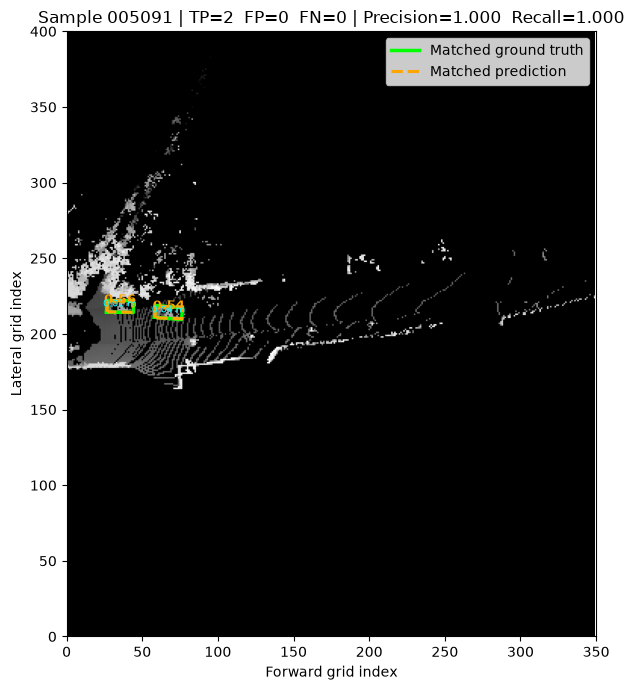

In [20]:
# Match predictions with ground-truth boxes using center distance.
# This uses the same one-to-one 2-metre rule as the validation metrics.

match_distance_m = 2.0

matched_pairs = []
matched_gt_indices = set()
matched_detection_indices = set()

# Process high-confidence predictions first.
for detection_index, detection in sorted(
    enumerate(detections),
    key=lambda item: item[1]["score"],
    reverse=True,
):
    best_gt_index = None
    best_distance = match_distance_m

    for gt_index, gt_box in enumerate(gt_boxes):
        # A ground-truth box can only match one prediction.
        if gt_index in matched_gt_indices:
            continue

        distance = np.hypot(
            detection["center_x"] - gt_box["center_x"],
            detection["center_y"] - gt_box["center_y"],
        )

        if distance <= best_distance:
            best_distance = distance
            best_gt_index = gt_index

    if best_gt_index is not None:
        matched_gt_indices.add(best_gt_index)
        matched_detection_indices.add(detection_index)

        matched_pairs.append(
            (detection_index, best_gt_index, best_distance)
        )


# Classify all unmatched objects.
false_positive_indices = (
    set(range(len(detections))) - matched_detection_indices
)

missed_gt_indices = (
    set(range(len(gt_boxes))) - matched_gt_indices
)


# Calculate frame-level metrics.
true_positives = len(matched_pairs)
false_positives = len(false_positive_indices)
false_negatives = len(missed_gt_indices)

precision = (
    true_positives / (true_positives + false_positives)
    if true_positives + false_positives > 0
    else 0.0
)

recall = (
    true_positives / (true_positives + false_negatives)
    if true_positives + false_negatives > 0
    else 0.0
)

print("True positives:", true_positives)
print("False positives:", false_positives)
print("False negatives:", false_negatives)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")


def box_to_bev_corners(box):
    """Convert one metric LiDAR box to closed BEV-grid corners."""

    corners = box_corners_from_parameters(
        box["center_x"],
        box["center_y"],
        box["length"],
        box["width"],
        box["yaw"],
    )

    corners = lidar_xy_to_bev(corners)

    return np.vstack([corners, corners[0]])


def box_to_bev_center(box):
    """Convert one metric LiDAR center to a BEV-grid center."""

    metric_center = np.array(
        [[box["center_x"], box["center_y"]]],
        dtype=np.float32,
    )

    return lidar_xy_to_bev(metric_center)[0]


# Create the plot.
fig, ax = plt.subplots(figsize=(12, 7))

ax.imshow(
    bev[0].T,
    origin="lower",
    cmap="gray",
    aspect="equal",
)


# ---------------------------------------------------------
# Ground truth
#
# Green   = ground truth successfully detected
# Magenta = ground truth missed by the model
# ---------------------------------------------------------

for gt_index, gt_box in enumerate(gt_boxes):
    is_matched = gt_index in matched_gt_indices

    if is_matched:
        color = "lime"
        label = "Matched ground truth"
    else:
        color = "magenta"
        label = "Missed ground truth"

    closed_corners = box_to_bev_corners(gt_box)

    ax.plot(
        closed_corners[:, 0],
        closed_corners[:, 1],
        color=color,
        linestyle="-",
        linewidth=2.5,
        label=label,
        zorder=3,
    )


# ---------------------------------------------------------
# Predictions
#
# Orange = prediction matched to a real car
# Red    = false positive
# ---------------------------------------------------------

for detection_index, detection in enumerate(detections):
    is_matched = detection_index in matched_detection_indices

    if is_matched:
        color = "orange"
        label = "Matched prediction"
    else:
        color = "red"
        label = "False positive"

    closed_corners = box_to_bev_corners(detection)
    center = box_to_bev_center(detection)

    ax.plot(
        closed_corners[:, 0],
        closed_corners[:, 1],
        color=color,
        linestyle="--",
        linewidth=2.2,
        label=label,
        zorder=4,
    )

    ax.text(
        center[0],
        center[1],
        f'{detection["score"]:.2f}',
        color=color,
        fontsize=9,
        fontweight="bold",
        horizontalalignment="center",
        verticalalignment="bottom",
        zorder=6,
    )


# ---------------------------------------------------------
# Connect each matched prediction to its ground truth.
# ---------------------------------------------------------

for detection_index, gt_index, distance in matched_pairs:
    prediction_center = box_to_bev_center(
        detections[detection_index]
    )

    gt_center = box_to_bev_center(
        gt_boxes[gt_index]
    )

    ax.plot(
        [prediction_center[0], gt_center[0]],
        [prediction_center[1], gt_center[1]],
        color="cyan",
        linestyle=":",
        linewidth=1.4,
        zorder=2,
    )

    midpoint = (
        prediction_center + gt_center
    ) / 2.0

    ax.text(
        midpoint[0],
        midpoint[1],
        f"{distance:.2f} m",
        color="cyan",
        fontsize=7,
        horizontalalignment="center",
        zorder=6,
    )


# Remove duplicate entries from the legend.
handles, labels = ax.get_legend_handles_labels()

unique_legend = {}

for handle, label in zip(handles, labels):
    if label not in unique_legend:
        unique_legend[label] = handle

ax.legend(
    unique_legend.values(),
    unique_legend.keys(),
    loc="upper right",
)


ax.set_xlim(0, bev.shape[1])
ax.set_ylim(0, bev.shape[2])

ax.set_xlabel("Forward grid index")
ax.set_ylabel("Lateral grid index")

ax.set_title(
    f"Sample {sample['id']} | "
    f"TP={true_positives}  "
    f"FP={false_positives}  "
    f"FN={false_negatives} | "
    f"Precision={precision:.3f}  "
    f"Recall={recall:.3f}"
)

fig.tight_layout()
plt.show()